# 3CSD Group 8 Implementation

**Evaluating Algorithmic Bias and Feature Thresholds in Predicting Geopolitical Attack Success Using Logistic Regression, XGBoost, and a Feedforward Neural Network on the Global Terrorism Database**

This notebook is the main implementation artifact for the project. It is intentionally self-contained: data loading, preprocessing, model training, evaluation, threshold simulation, subgroup error analysis, and interpretability are all included here.

**Research focus:** predict the binary GTD `success` outcome using pre-attack or attack-design variables while studying model assumptions, class imbalance, decision thresholds, and subgroup error disparities.


## 1. Environment and Reproducibility

Run this notebook from the project root or from the `notebooks/` folder. The raw GTD files should be located at:

```text
data-raw/globalterrorismdb_0522dist.xlsx
data-raw/globalterrorismdb_2021Jan-June_1222dist.xlsx
```

For a quick classroom check, set `USE_SAMPLE = True`. For final results, set `USE_SAMPLE = False`.


### Optional GPU Use

This notebook can use a CUDA-capable GPU for **XGBoost and the PyTorch feedforward neural network** by setting `USE_GPU = True` in the setup cell. Logistic Regression remains CPU-based because scikit-learn does not use CUDA for that estimator.

Note: XGBoost is trained with `device="cuda"` when CUDA is available. Because the preprocessing pipeline outputs a CPU matrix, XGBoost may display a prediction-time device warning during evaluation; this does not stop training or invalidate the results.


In [42]:
from pathlib import Path
import random
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy import sparse

import torch
from torch import nn

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

SHAP_AVAILABLE = None  # Checked lazily in the interpretability section.

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

MAIN_DATA_PATH = PROJECT_ROOT / "data-raw" / "globalterrorismdb_0522dist.xlsx"
EXTRA_2021_DATA_PATH = PROJECT_ROOT / "data-raw" / "globalterrorismdb_2021Jan-June_1222dist.xlsx"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

for directory in [MODELS_DIR, FIGURES_DIR, TABLES_DIR, PROCESSED_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

USE_SAMPLE = False          # Set True for a quick run; False for final results.
SAMPLE_NROWS = 5000         # Used only when USE_SAMPLE is True.
SAVE_PROCESSED_SPLITS = False # Set True only if you want local Parquet/CSV split exports.
RUN_SHAP = True             # SHAP for XGBoost can take time on the full test set.
SHAP_SAMPLE_SIZE = 1500
USE_GPU = True              # Set True to use CUDA GPU for XGBoost and PyTorch NN when available.

TORCH_DEVICE = "cuda" if USE_GPU and torch.cuda.is_available() else "cpu"
XGBOOST_DEVICE = "cuda" if USE_GPU and torch.cuda.is_available() else "cpu"

print("Project root:", PROJECT_ROOT)
print("Main dataset:", MAIN_DATA_PATH)
print("Extra 2021 dataset:", EXTRA_2021_DATA_PATH)
print("XGBoost available:", XGBOOST_AVAILABLE)
print("SHAP import deferred until interpretability section")
print("XGBoost device requested:", XGBOOST_DEVICE if XGBOOST_AVAILABLE else "not available")
print("PyTorch version:", torch.__version__)
print("PyTorch CUDA available:", torch.cuda.is_available())
print("PyTorch device selected:", TORCH_DEVICE)


Project root: c:\Documents\Compsci\CSELEC2C\Project
Main dataset: c:\Documents\Compsci\CSELEC2C\Project\data-raw\globalterrorismdb_0522dist.xlsx
Extra 2021 dataset: c:\Documents\Compsci\CSELEC2C\Project\data-raw\globalterrorismdb_2021Jan-June_1222dist.xlsx
XGBoost available: True
SHAP import deferred until interpretability section
XGBoost device requested: cuda
PyTorch version: 2.5.1
PyTorch CUDA available: True
PyTorch device selected: cuda


## 2. Modeling Assumptions and Feature Selection

The target is `success`, a binary GTD field indicating whether the incident was coded as successful. To reduce leakage, the notebook excludes casualty, property-damage, ransom, and hostage-outcome variables because these are consequences or post-event descriptors.

The selected variables are mostly temporal, geopolitical, tactical, target, weapon, and claim-related fields.


In [43]:
ID_COLUMN = "eventid"
TARGET = "success"

NUMERIC_FEATURES = [
    "iyear", "imonth", "iday", "extended", "latitude", "longitude",
    "specificity", "vicinity", "doubtterr", "multiple", "suicide",
    "guncertain1", "individual", "claimed", "INT_LOG", "INT_IDEO",
    "INT_MISC", "INT_ANY",
]

CATEGORICAL_FEATURES = [
    "region_txt", "country_txt", "attacktype1_txt", "targtype1_txt",
    "targsubtype1_txt", "natlty1_txt", "weaptype1_txt", "weapsubtype1_txt",
]

LEAKAGE_COLUMNS_EXCLUDED = [
    "nkill", "nkillus", "nkillter", "nwound", "nwoundus", "nwoundte",
    "property", "propextent", "propextent_txt", "propvalue", "ransom",
    "ransomamt", "ransompaid", "hostkidoutcome", "hostkidoutcome_txt", "nreleased",
]

USECOLS = list(dict.fromkeys([ID_COLUMN] + NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET]))
USECOLS


['eventid',
 'iyear',
 'imonth',
 'iday',
 'extended',
 'latitude',
 'longitude',
 'specificity',
 'vicinity',
 'doubtterr',
 'multiple',
 'suicide',
 'guncertain1',
 'individual',
 'claimed',
 'INT_LOG',
 'INT_IDEO',
 'INT_MISC',
 'INT_ANY',
 'region_txt',
 'country_txt',
 'attacktype1_txt',
 'targtype1_txt',
 'targsubtype1_txt',
 'natlty1_txt',
 'weaptype1_txt',
 'weapsubtype1_txt',
 'success']

## 3. Load and Clean the GTD Data

The final run uses the real GTD dataset. The main 1970-2022 workbook is loaded first, then the separate Jan-June 2021 workbook is always loaded and deduplicated by `eventid`. Synthetic data are not used for testing or validation.


In [44]:
if not MAIN_DATA_PATH.exists():
    raise FileNotFoundError(f"Missing main dataset: {MAIN_DATA_PATH}")

nrows = SAMPLE_NROWS if USE_SAMPLE else None
raw_frames = []

main_df = pd.read_excel(MAIN_DATA_PATH, usecols=USECOLS, nrows=nrows)
main_df["source_file"] = MAIN_DATA_PATH.name
raw_frames.append(main_df)

if EXTRA_2021_DATA_PATH.exists() and not USE_SAMPLE:
    extra_2021_df = pd.read_excel(EXTRA_2021_DATA_PATH, usecols=USECOLS)
    extra_2021_df["source_file"] = EXTRA_2021_DATA_PATH.name
    raw_frames.append(extra_2021_df)
    print("Loaded required 2021 file:", extra_2021_df.shape)
elif USE_SAMPLE:
    print("Skipping extra 2021 file during sample mode to keep quick runs fast.")
else:
    raise FileNotFoundError(f"Missing required 2021 dataset: {EXTRA_2021_DATA_PATH}")

raw_df = pd.concat(raw_frames, ignore_index=True)
raw_before_dedupe = len(raw_df)
raw_df = raw_df.drop_duplicates(subset=ID_COLUMN, keep="first").reset_index(drop=True)
raw_after_dedupe = len(raw_df)

print("Raw shape after deduplication:", raw_df.shape)
print("Duplicate eventids removed:", raw_before_dedupe - raw_after_dedupe)
print("Year range:", int(raw_df["iyear"].min()), "to", int(raw_df["iyear"].max()))
print(raw_df[[ID_COLUMN, "iyear", "region_txt", "attacktype1_txt", TARGET, "source_file"]].head())


Loaded required 2021 file: (4960, 29)
Raw shape after deduplication: (214666, 29)
Duplicate eventids removed: 0
Year range: 1970 to 2021
        eventid  iyear                   region_txt  \
0  197000000001   1970  Central America & Caribbean   
1  197000000002   1970                North America   
2  197001000001   1970               Southeast Asia   
3  197001000002   1970               Western Europe   
4  197001000003   1970                    East Asia   

                  attacktype1_txt  success                      source_file  
0                   Assassination        1  globalterrorismdb_0522dist.xlsx  
1     Hostage Taking (Kidnapping)        1  globalterrorismdb_0522dist.xlsx  
2                   Assassination        1  globalterrorismdb_0522dist.xlsx  
3               Bombing/Explosion        1  globalterrorismdb_0522dist.xlsx  
4  Facility/Infrastructure Attack        1  globalterrorismdb_0522dist.xlsx  


In [45]:
df = raw_df.copy()
df = df[df[TARGET].isin([0, 1])].copy()

present_numeric = [c for c in NUMERIC_FEATURES if c in df.columns]
present_categorical = [c for c in CATEGORICAL_FEATURES if c in df.columns]

for col in present_numeric:
    df[col] = pd.to_numeric(df[col], errors="coerce")
for col in present_categorical:
    df[col] = df[col].astype("string").fillna("Unknown")

X = df[present_numeric + present_categorical].copy()
y = df[TARGET].astype(int).copy()

class_balance = y.value_counts(normalize=True).rename("proportion").to_frame()
class_balance["count"] = y.value_counts()
class_balance


,proportion,count
success,,
1,0.882888,189526
0,0.117112,25140


## 4. Temporal Train-Validation-Test Split

A temporal split better approximates forward-looking use than a random split. For the final dataset:

- Train: 1970-2014
- Validation: 2015-2017
- Test: 2018 onward

When `USE_SAMPLE = True`, the split years are moved earlier so the first 5,000 rows still contain train, validation, and test partitions.


In [46]:
if USE_SAMPLE:
    TRAIN_END = 1970
    VALID_END = 1971
else:
    TRAIN_END = 2014
    VALID_END = 2017

train_mask = X["iyear"] <= TRAIN_END
valid_mask = (X["iyear"] > TRAIN_END) & (X["iyear"] <= VALID_END)
test_mask = X["iyear"] > VALID_END

X_train, y_train = X.loc[train_mask].copy(), y.loc[train_mask].copy()
X_valid, y_valid = X.loc[valid_mask].copy(), y.loc[valid_mask].copy()
X_test, y_test = X.loc[test_mask].copy(), y.loc[test_mask].copy()

if min(len(X_train), len(X_valid), len(X_test)) == 0:
    raise ValueError("Temporal split produced an empty partition. Adjust USE_SAMPLE or split years.")

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n": [len(X_train), len(X_valid), len(X_test)],
    "start_year": [X_train.iyear.min(), X_valid.iyear.min(), X_test.iyear.min()],
    "end_year": [X_train.iyear.max(), X_valid.iyear.max(), X_test.iyear.max()],
    "success_rate": [y_train.mean(), y_valid.mean(), y_test.mean()],
})
split_summary


,split,n,start_year,end_year,success_rate
0,train,142325,1970,2014,0.909229
1,validation,40553,2015,2017,0.818706
2,test,31788,2018,2021,0.846829


In [47]:
if SAVE_PROCESSED_SPLITS:
    X_train.to_parquet(PROCESSED_DIR / "X_train.parquet", index=False)
    X_valid.to_parquet(PROCESSED_DIR / "X_valid.parquet", index=False)
    X_test.to_parquet(PROCESSED_DIR / "X_test.parquet", index=False)
    y_train.to_frame(TARGET).to_csv(PROCESSED_DIR / "y_train.csv", index=False)
    y_valid.to_frame(TARGET).to_csv(PROCESSED_DIR / "y_valid.csv", index=False)
    y_test.to_frame(TARGET).to_csv(PROCESSED_DIR / "y_test.csv", index=False)
    print("Saved processed split files to", PROCESSED_DIR)
else:
    print("Processed split export skipped. Set SAVE_PROCESSED_SPLITS = True to write Parquet/CSV files.")


Processed split export skipped. Set SAVE_PROCESSED_SPLITS = True to write Parquet/CSV files.


## 5. Preprocessing Pipeline

Numeric variables are median-imputed and standardized. Categorical variables are imputed with `Unknown` and one-hot encoded. Rare categories are grouped when the local scikit-learn version supports `min_frequency`.


In [48]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=20,
            sparse_output=True,
        )
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def make_preprocessor():
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", make_one_hot_encoder()),
    ])
    return ColumnTransformer([
        ("num", numeric_pipeline, present_numeric),
        ("cat", categorical_pipeline, present_categorical),
    ], remainder="drop", sparse_threshold=0.3)

preprocessor_preview = make_preprocessor()
preprocessor_preview


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 6. PyTorch Feedforward Neural Network Class

The neural network below is implemented in PyTorch so it can use CUDA on Windows or WSL2 when the installed PyTorch build and NVIDIA drivers support it. It follows the scikit-learn estimator interface enough to work inside the same preprocessing and evaluation pipeline.


In [49]:
class TorchMLPClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        hidden_layers=(128, 64),
        lr=1e-3,
        weight_decay=1e-4,
        batch_size=512,
        max_epochs=30,
        patience=5,
        use_gpu=True,
        random_state=42,
        verbose=True,
    ):
        self.hidden_layers = hidden_layers
        self.lr = lr
        self.weight_decay = weight_decay
        self.batch_size = batch_size
        self.max_epochs = max_epochs
        self.patience = patience
        self.use_gpu = use_gpu
        self.random_state = random_state
        self.verbose = verbose

    def _device(self):
        return torch.device("cuda" if self.use_gpu and torch.cuda.is_available() else "cpu")

    def _build_network(self, input_dim):
        layers = []
        previous_dim = input_dim
        for hidden_dim in self.hidden_layers:
            layers.extend([
                nn.Linear(previous_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.20),
            ])
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        return nn.Sequential(*layers)

    def _to_tensor(self, X_batch):
        if sparse.issparse(X_batch):
            X_batch = X_batch.toarray()
        return torch.as_tensor(X_batch, dtype=torch.float32, device=self.device_)

    def fit(self, X, y):
        torch.manual_seed(self.random_state)
        np.random.seed(self.random_state)
        self.classes_ = np.array([0, 1])
        self.device_ = self._device()
        self.device_name_ = str(self.device_)
        y_array = np.asarray(y).astype(np.float32)
        n_samples, input_dim = X.shape
        self.network_ = self._build_network(input_dim).to(self.device_)

        indices = np.arange(n_samples)
        rng = np.random.default_rng(self.random_state)
        rng.shuffle(indices)
        valid_size = max(int(0.10 * n_samples), 1)
        valid_idx = indices[:valid_size]
        train_idx = indices[valid_size:]

        positives = max(float((y_array[train_idx] == 1).sum()), 1.0)
        negatives = max(float((y_array[train_idx] == 0).sum()), 1.0)
        pos_weight = torch.tensor([negatives / positives], dtype=torch.float32, device=self.device_)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        optimizer = torch.optim.AdamW(self.network_.parameters(), lr=self.lr, weight_decay=self.weight_decay)

        best_state = None
        best_valid_loss = float("inf")
        stale_epochs = 0

        for epoch in range(1, self.max_epochs + 1):
            self.network_.train()
            rng.shuffle(train_idx)
            batch_losses = []
            for start in range(0, len(train_idx), self.batch_size):
                batch_idx = train_idx[start:start + self.batch_size]
                xb = self._to_tensor(X[batch_idx])
                yb = torch.as_tensor(y_array[batch_idx], dtype=torch.float32, device=self.device_).view(-1, 1)
                optimizer.zero_grad(set_to_none=True)
                logits = self.network_(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()
                batch_losses.append(float(loss.detach().cpu()))

            valid_loss = self._validation_loss(X, y_array, valid_idx, criterion)
            if self.verbose and (epoch == 1 or epoch % 5 == 0):
                print(f"Torch NN epoch {epoch:02d} | train_loss={np.mean(batch_losses):.4f} | valid_loss={valid_loss:.4f} | device={self.device_name_}")
            if valid_loss < best_valid_loss:
                best_valid_loss = valid_loss
                best_state = {k: v.detach().cpu().clone() for k, v in self.network_.state_dict().items()}
                stale_epochs = 0
            else:
                stale_epochs += 1
                if stale_epochs >= self.patience:
                    break

        if best_state is not None:
            self.network_.load_state_dict(best_state)
            self.network_.to(self.device_)
        return self

    def _validation_loss(self, X, y_array, valid_idx, criterion):
        self.network_.eval()
        losses = []
        with torch.no_grad():
            for start in range(0, len(valid_idx), self.batch_size):
                batch_idx = valid_idx[start:start + self.batch_size]
                xb = self._to_tensor(X[batch_idx])
                yb = torch.as_tensor(y_array[batch_idx], dtype=torch.float32, device=self.device_).view(-1, 1)
                logits = self.network_(xb)
                losses.append(float(criterion(logits, yb).detach().cpu()))
        return float(np.mean(losses)) if losses else float("inf")

    def predict_proba(self, X):
        self.network_.eval()
        probabilities = []
        with torch.no_grad():
            for start in range(0, X.shape[0], self.batch_size):
                xb = self._to_tensor(X[start:start + self.batch_size])
                logits = self.network_(xb)
                probs = torch.sigmoid(logits).detach().cpu().numpy().ravel()
                probabilities.append(probs)
        positive = np.concatenate(probabilities)
        return np.column_stack([1.0 - positive, positive])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

    def save_torch_state(self, path):
        torch.save({
            "state_dict": {k: v.detach().cpu() for k, v in self.network_.state_dict().items()},
            "hidden_layers": self.hidden_layers,
            "device_name": self.device_name_,
        }, path)


## 7. Model Training

The notebook trains three models:

1. **Logistic Regression**: interpretable baseline with class weighting.
2. **XGBoost**: SOTA nonlinear tree boosting model for tabular data.
3. **PyTorch Feedforward Neural Network**: nonlinear neural baseline implemented as a CUDA-compatible MLP.


In [50]:
models = {}

models["logistic_regression"] = Pipeline([
    ("preprocessor", make_preprocessor()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        solver="saga",
        random_state=RANDOM_STATE,
    )),
])

if XGBOOST_AVAILABLE:
    positives = max(int((y_train == 1).sum()), 1)
    negatives = max(int((y_train == 0).sum()), 1)
    print(f"XGBoost will request device={XGBOOST_DEVICE}. If CUDA is unavailable, XGBoost may warn and fall back to CPU.")
    models["xgboost"] = Pipeline([
        ("preprocessor", make_preprocessor()),
        ("model", XGBClassifier(
            n_estimators=350,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=negatives / positives,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist",
            device=XGBOOST_DEVICE,
        )),
    ])
else:
    print("XGBoost is not installed, so the SOTA tabular model will be skipped.")

models["feedforward_torch_nn"] = Pipeline([
    ("preprocessor", make_preprocessor()),
    ("model", TorchMLPClassifier(
        hidden_layers=(128, 64),
        lr=1e-3,
        weight_decay=1e-4,
        batch_size=512,
        max_epochs=30,
        patience=5,
        use_gpu=USE_GPU,
        random_state=RANDOM_STATE,
        verbose=True,
    )),
])

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    if name == "feedforward_torch_nn":
        joblib.dump(model.named_steps["preprocessor"], MODELS_DIR / "feedforward_torch_preprocessor.joblib")
        model.named_steps["model"].save_torch_state(MODELS_DIR / "feedforward_torch_nn.pt")
    else:
        joblib.dump(model, MODELS_DIR / f"{name}.joblib")

print("Trained models:", list(models))
if "feedforward_torch_nn" in models:
    print("PyTorch NN trained on:", models["feedforward_torch_nn"].named_steps["model"].device_name_)


XGBoost will request device=cuda. If CUDA is unavailable, XGBoost may warn and fall back to CPU.
Training logistic_regression...
Training xgboost...
Training feedforward_torch_nn...
Torch NN epoch 01 | train_loss=0.1009 | valid_loss=0.0935 | device=cuda
Torch NN epoch 05 | train_loss=0.0847 | valid_loss=0.0888 | device=cuda
Torch NN epoch 10 | train_loss=0.0769 | valid_loss=0.0916 | device=cuda
Trained models: ['logistic_regression', 'xgboost', 'feedforward_torch_nn']
PyTorch NN trained on: cuda


## 8. XGBoost Training/Validation Learning Curves

The proposal studies model behavior, not only final scores. This section refits the XGBoost component with both train and validation monitoring to diagnose overfitting. A widening train-validation gap, validation log loss increasing while training log loss decreases, or validation PR-AUC peaking early can indicate overfitting.


Best validation PR-AUC iteration: 344
Best validation logloss iteration: 349
Final train-valid PR-AUC gap: 0.04074503187516132


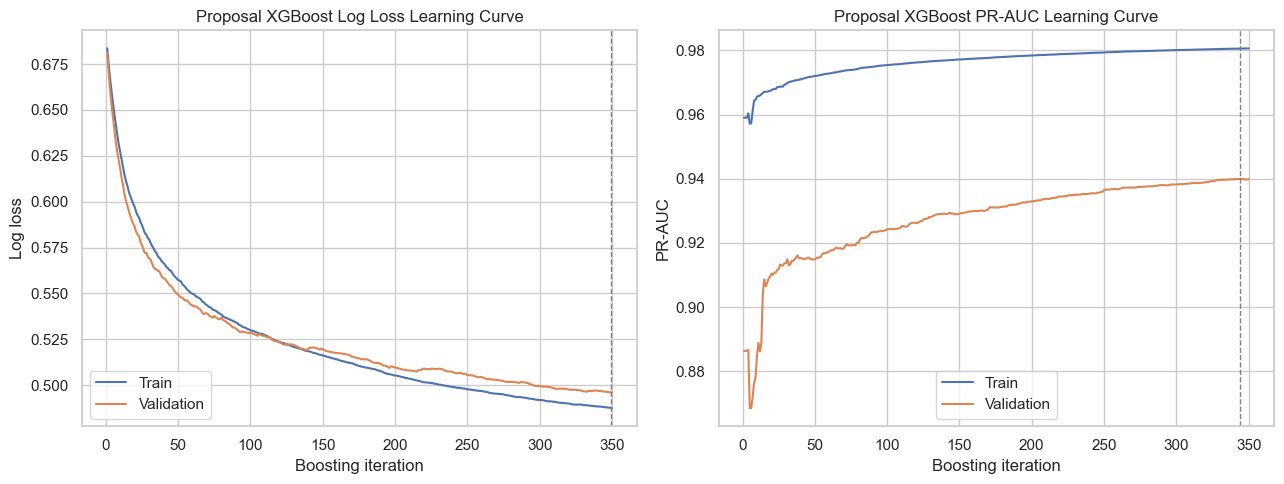

,iteration,train_logloss,valid_logloss,train_aucpr,valid_aucpr
345,346,0.487948,0.496408,0.980584,0.939925
346,347,0.487818,0.496292,0.980607,0.939747
347,348,0.487736,0.496178,0.980610,0.939767
348,349,0.487687,0.496037,0.980617,0.939779
349,350,0.487471,0.496239,0.980633,0.939888


In [51]:
if "xgboost" in models:
    xgb_pipeline_for_curves = models["xgboost"]
    xgb_preprocessor_for_curves = xgb_pipeline_for_curves.named_steps["preprocessor"]
    X_train_xgb_curve = xgb_preprocessor_for_curves.transform(X_train)
    X_valid_xgb_curve = xgb_preprocessor_for_curves.transform(X_valid)

    trained_xgb = xgb_pipeline_for_curves.named_steps["model"]
    xgb_curve_params = trained_xgb.get_params()
    xgb_curve_params.update({
        "eval_metric": ["logloss", "aucpr"],
        "random_state": RANDOM_STATE,
    })
    xgb_curve_model = XGBClassifier(**xgb_curve_params)
    xgb_curve_model.fit(
        X_train_xgb_curve, y_train,
        eval_set=[(X_train_xgb_curve, y_train), (X_valid_xgb_curve, y_valid)],
        verbose=False,
    )

    xgb_evals = xgb_curve_model.evals_result()
    train_key, valid_key = list(xgb_evals.keys())[0], list(xgb_evals.keys())[1]
    xgb_learning_curve_df = pd.DataFrame({
        "iteration": np.arange(1, len(xgb_evals[train_key]["logloss"]) + 1),
        "train_logloss": xgb_evals[train_key]["logloss"],
        "valid_logloss": xgb_evals[valid_key]["logloss"],
        "train_aucpr": xgb_evals[train_key]["aucpr"],
        "valid_aucpr": xgb_evals[valid_key]["aucpr"],
    })
    xgb_learning_curve_df.to_csv(TABLES_DIR / "proposal_xgboost_learning_curves.csv", index=False)

    best_valid_aucpr_iter = int(xgb_learning_curve_df.loc[xgb_learning_curve_df["valid_aucpr"].idxmax(), "iteration"])
    best_valid_logloss_iter = int(xgb_learning_curve_df.loc[xgb_learning_curve_df["valid_logloss"].idxmin(), "iteration"])
    print("Best validation PR-AUC iteration:", best_valid_aucpr_iter)
    print("Best validation logloss iteration:", best_valid_logloss_iter)
    print("Final train-valid PR-AUC gap:", float(xgb_learning_curve_df.iloc[-1]["train_aucpr"] - xgb_learning_curve_df.iloc[-1]["valid_aucpr"]))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(xgb_learning_curve_df["iteration"], xgb_learning_curve_df["train_logloss"], label="Train")
    axes[0].plot(xgb_learning_curve_df["iteration"], xgb_learning_curve_df["valid_logloss"], label="Validation")
    axes[0].axvline(best_valid_logloss_iter, linestyle="--", color="gray", linewidth=1)
    axes[0].set_title("Proposal XGBoost Log Loss Learning Curve")
    axes[0].set_xlabel("Boosting iteration")
    axes[0].set_ylabel("Log loss")
    axes[0].legend()

    axes[1].plot(xgb_learning_curve_df["iteration"], xgb_learning_curve_df["train_aucpr"], label="Train")
    axes[1].plot(xgb_learning_curve_df["iteration"], xgb_learning_curve_df["valid_aucpr"], label="Validation")
    axes[1].axvline(best_valid_aucpr_iter, linestyle="--", color="gray", linewidth=1)
    axes[1].set_title("Proposal XGBoost PR-AUC Learning Curve")
    axes[1].set_xlabel("Boosting iteration")
    axes[1].set_ylabel("PR-AUC")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "proposal_xgboost_learning_curves.png", dpi=180)
    plt.show()

    display(xgb_learning_curve_df.tail())
else:
    print("XGBoost is unavailable; learning curves skipped.")


## 9. Evaluation Metrics

We report ROC-AUC, average precision, accuracy, balanced accuracy, precision, recall, F1, false-positive rate, and false-negative rate. Average precision is useful because the target is imbalanced.


In [52]:
def predict_proba_positive(model, X_frame):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_frame)[:, 1]
    scores = model.decision_function(X_frame)
    return (scores - scores.min()) / (scores.max() - scores.min())


def metrics_at_threshold(y_true, y_proba, threshold=0.5):
    y_true = np.asarray(y_true)
    y_pred = (y_proba >= threshold).astype(int)
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "false_positive_rate": fp / (fp + tn) if (fp + tn) else 0.0,
        "false_negative_rate": fn / (fn + tp) if (fn + tp) else 0.0,
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
    }


def evaluate_split(models, X_frame, y_true, split_name):
    rows = []
    for name, model in models.items():
        proba = predict_proba_positive(model, X_frame)
        row = {
            "model": name,
            "split": split_name,
            "roc_auc": roc_auc_score(y_true, proba),
            "average_precision": average_precision_score(y_true, proba),
        }
        row.update(metrics_at_threshold(y_true, proba, threshold=0.5))
        rows.append(row)
    return pd.DataFrame(rows)

metrics_df = pd.concat([
    evaluate_split(models, X_valid, y_valid, "validation"),
    evaluate_split(models, X_test, y_test, "test"),
], ignore_index=True)

metrics_df.to_csv(TABLES_DIR / "model_metrics.csv", index=False)
metrics_df


,model,split,roc_auc,average_precision,threshold,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn
0,logistic_regression,validation,0.780362,0.931936,0.5,0.751313,0.708813,0.907287,0.775489,0.836227,0.357862,0.224511,25747,2631,4721,7454
1,xgboost,validation,0.796981,0.939900,0.5,0.774419,0.717312,0.907305,0.806903,0.854164,0.372280,0.193097,26790,2737,4615,6411
2,feedforward_torch_nn,validation,0.834543,0.952347,0.5,0.753680,0.744835,0.927194,0.758712,0.834534,0.269042,0.241288,25190,1978,5374,8011
3,logistic_regression,test,0.769711,0.943835,0.5,0.748364,0.692024,0.916557,0.773246,0.838824,0.389197,0.226754,20815,1895,2974,6104
4,xgboost,test,0.779661,0.947605,0.5,0.781427,0.693966,0.912982,0.820053,0.864026,0.432122,0.179947,22075,2104,2765,4844
5,feedforward_torch_nn,test,0.802758,0.950708,0.5,0.723166,0.725850,0.936581,0.721981,0.815398,0.270281,0.278019,19435,1316,3553,7484


## 10. Imbalance-Aware Baselines and Robust Metrics

Because successful attacks are the majority class, raw accuracy and success-class F1 can be misleading. These sanity-check baselines and additional metrics support the proposal's focus on imbalanced data and algorithmic bias.


In [53]:
from sklearn.metrics import brier_score_loss, matthews_corrcoef


def robust_binary_metrics(model_name, split_name, y_true, proba, threshold=0.50):
    y_true = np.asarray(y_true).astype(int)
    proba = np.asarray(proba, dtype=float)
    pred = (proba >= threshold).astype(int)
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    tp = int(((pred == 1) & (y_true == 1)).sum())
    tn = int(((pred == 0) & (y_true == 0)).sum())
    return {
        "model": model_name,
        "split": split_name,
        "threshold": float(threshold),
        "roc_auc": roc_auc_score(y_true, proba),
        "average_precision_success": average_precision_score(y_true, proba),
        "average_precision_failure": average_precision_score(1 - y_true, 1 - proba),
        "brier_score": brier_score_loss(y_true, proba),
        "mcc": matthews_corrcoef(y_true, pred),
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "false_positive_rate": fp / (fp + tn) if (fp + tn) else 0.0,
        "false_negative_rate": fn / (fn + tp) if (fn + tp) else 0.0,
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
    }


def empirical_group_rate_proba(X_reference, y_reference, X_eval, keys, smoothing=50.0):
    available_keys = [k for k in keys if k in X_reference.columns and k in X_eval.columns]
    global_rate = float(np.mean(y_reference))
    if not available_keys:
        return np.full(len(X_eval), global_rate)
    ref = X_reference[available_keys].astype("string").fillna("Unknown").copy()
    ref["__y__"] = np.asarray(y_reference).astype(float)
    ref["__key__"] = ref[available_keys].agg("||".join, axis=1)
    grouped = ref.groupby("__key__")["__y__"].agg(["sum", "count"])
    grouped["rate"] = (grouped["sum"] + smoothing * global_rate) / (grouped["count"] + smoothing)
    eval_keys = X_eval[available_keys].astype("string").fillna("Unknown").agg("||".join, axis=1)
    return eval_keys.map(grouped["rate"]).fillna(global_rate).to_numpy(dtype=float)

robust_rows = []
train_prevalence = float(np.mean(y_train))
for split_name, X_split, y_split in [("validation", X_valid, y_valid), ("test", X_test, y_test)]:
    robust_rows.append(robust_binary_metrics("always_success_baseline", split_name, y_split, np.ones(len(y_split)), 0.50))
    robust_rows.append(robust_binary_metrics("train_prevalence_constant_baseline", split_name, y_split, np.full(len(y_split), train_prevalence), 0.50))
    empirical_proba = empirical_group_rate_proba(X_train, y_train, X_split, ["country_txt", "attacktype1_txt", "targtype1_txt"], smoothing=50.0)
    robust_rows.append(robust_binary_metrics("smoothed_country_attack_target_rate_baseline", split_name, y_split, empirical_proba, 0.50))
    for model_name, model in models.items():
        proba = predict_proba_positive(model, X_split)
        robust_rows.append(robust_binary_metrics(model_name, split_name, y_split, proba, 0.50))

robust_metrics_df = pd.DataFrame(robust_rows)
robust_metrics_df.to_csv(TABLES_DIR / "proposal_robust_model_metrics.csv", index=False)
robust_metrics_df.sort_values(["split", "average_precision_failure", "balanced_accuracy"], ascending=[True, False, False])


,model,split,threshold,roc_auc,average_precision_success,average_precision_failure,brier_score,mcc,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn
11,feedforward_torch_nn,test,0.5,0.802758,0.950708,0.491864,0.191790,0.341707,0.723166,0.725850,0.936581,0.721981,0.815398,0.270281,0.278019,19435,1316,3553,7484
10,xgboost,test,0.5,0.779661,0.947605,0.478004,0.162394,0.327432,0.781427,0.693966,0.912982,0.820053,0.864026,0.432122,0.179947,22075,2104,2765,4844
9,logistic_regression,test,0.5,0.769711,0.943835,0.455160,0.181485,0.306219,0.748364,0.692024,0.916557,0.773246,0.838824,0.389197,0.226754,20815,1895,2974,6104
8,smoothed_country_attack_target_rate_baseline,test,0.5,0.724574,0.924021,0.394372,0.116833,0.204047,0.854096,0.536171,0.856371,0.994502,0.920282,0.922161,0.005498,26771,4490,379,148
6,always_success_baseline,test,0.5,0.500000,0.846829,0.153171,0.153171,0.000000,0.846829,0.500000,0.846829,1.000000,0.917063,1.000000,0.000000,26919,4869,0,0
7,train_prevalence_constant_baseline,test,0.5,0.500000,0.846829,0.153171,0.133603,0.000000,0.846829,0.500000,0.846829,1.000000,0.917063,1.000000,0.000000,26919,4869,0,0
5,feedforward_torch_nn,validation,0.5,0.834543,0.952347,0.594059,0.168607,0.401184,0.753680,0.744835,0.927194,0.758712,0.834534,0.269042,0.241288,25190,1978,5374,8011
4,xgboost,validation,0.5,0.796981,0.939900,0.567509,0.161846,0.376334,0.774419,0.717312,0.907305,0.806903,0.854164,0.372280,0.193097,26790,2737,4615,6411
2,smoothed_country_attack_target_rate_baseline,validation,0.5,0.755625,0.913104,0.532376,0.124446,0.365804,0.848445,0.593138,0.847509,0.993675,0.914790,0.807399,0.006325,32991,5936,1416,210
3,logistic_regression,validation,0.5,0.780362,0.931936,0.530547,0.175461,0.351028,0.751313,0.708813,0.907287,0.775489,0.836227,0.357862,0.224511,25747,2631,4721,7454


## 11. Bootstrap Confidence Intervals and Calibration

Conference-style evaluation should report uncertainty, not only point estimates. This section computes bootstrap confidence intervals for key temporal test metrics and draws calibration curves because threshold-based decisions depend on probability quality.


In [ ]:
from sklearn.calibration import calibration_curve

N_BOOTSTRAP = 300
BOOTSTRAP_RANDOM_STATE = RANDOM_STATE

def metric_bundle_for_ci(y_true, proba, threshold=0.50):
    y_true = np.asarray(y_true).astype(int)
    pred = (np.asarray(proba) >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, proba),
        "average_precision_success": average_precision_score(y_true, proba),
        "average_precision_failure": average_precision_score(1 - y_true, 1 - np.asarray(proba)),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "mcc": matthews_corrcoef(y_true, pred),
    }

def bootstrap_ci_for_model(model_name, y_true, proba, threshold=0.50, n_bootstrap=N_BOOTSTRAP):
    rng = np.random.default_rng(BOOTSTRAP_RANDOM_STATE)
    y_true = np.asarray(y_true).astype(int)
    proba = np.asarray(proba, dtype=float)
    rows = []
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        metrics = metric_bundle_for_ci(y_true[idx], proba[idx], threshold)
        rows.append(metrics)
    boot = pd.DataFrame(rows)
    point = metric_bundle_for_ci(y_true, proba, threshold)
    ci_rows = []
    for metric in point:
        ci_rows.append({
            "model": model_name,
            "metric": metric,
            "point_estimate": point[metric],
            "ci_lower_95": boot[metric].quantile(0.025),
            "ci_upper_95": boot[metric].quantile(0.975),
            "n_bootstrap": len(boot),
        })
    return pd.DataFrame(ci_rows)

ci_frames = []
for model_name, model in models.items():
    test_proba = predict_proba_positive(model, X_test)
    ci_frames.append(bootstrap_ci_for_model(model_name, y_test, test_proba, threshold=0.50))

bootstrap_ci_df = pd.concat(ci_frames, ignore_index=True)
bootstrap_ci_df.to_csv(TABLES_DIR / "proposal_bootstrap_confidence_intervals.csv", index=False)
display(bootstrap_ci_df)

# Calibration curves for all proposal models.
calibration_rows = []
plt.figure(figsize=(7, 6))
for model_name, model in models.items():
    test_proba = predict_proba_positive(model, X_test)
    frac_pos, mean_pred = calibration_curve(y_test, test_proba, n_bins=10, strategy="quantile")
    brier = brier_score_loss(y_test, test_proba)
    for bin_id, (mp, fp_rate) in enumerate(zip(mean_pred, frac_pos), start=1):
        calibration_rows.append({
            "model": model_name,
            "bin": bin_id,
            "mean_predicted_probability": mp,
            "observed_success_rate": fp_rate,
            "brier_score": brier,
        })
    plt.plot(mean_pred, frac_pos, marker="o", label=f"{model_name} | Brier={brier:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1, label="Perfect calibration")
plt.xlabel("Mean predicted success probability")
plt.ylabel("Observed success rate")
plt.title("Calibration curves on temporal test set")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "proposal_calibration_curves.png", dpi=180)
plt.show()

calibration_df = pd.DataFrame(calibration_rows)
calibration_df.to_csv(TABLES_DIR / "proposal_calibration_curves.csv", index=False)
calibration_df


## 12. ROC, Precision-Recall, and Confusion Matrix Plots


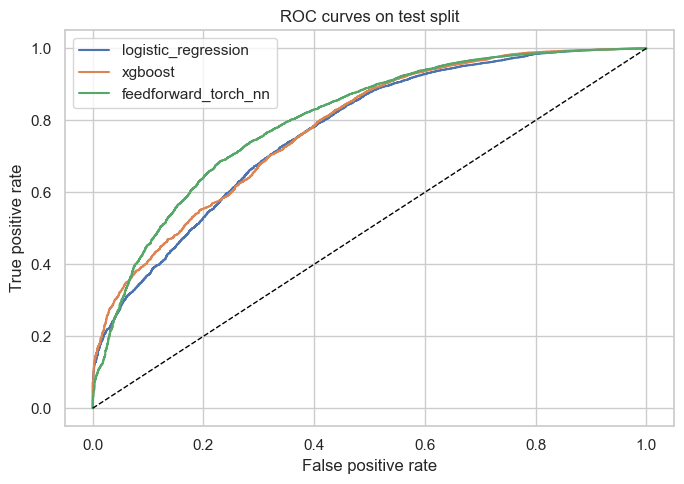

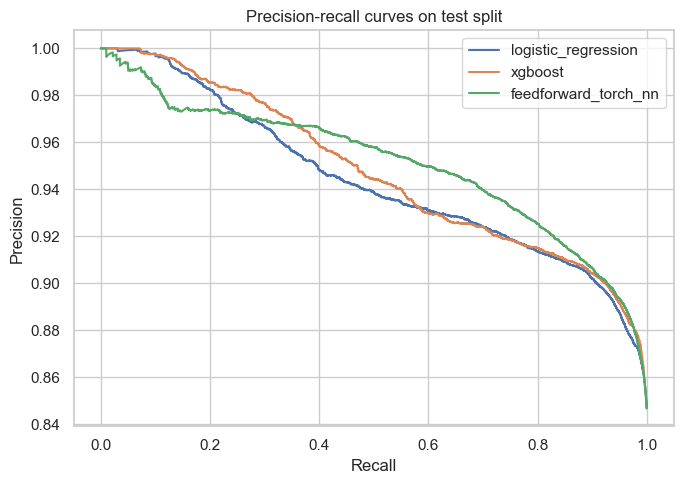

In [54]:
plt.figure(figsize=(7, 5))
for name, model in models.items():
    proba = predict_proba_positive(model, X_test)
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=name)
plt.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves on test split")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_curves_test.png", dpi=180)
plt.show()

plt.figure(figsize=(7, 5))
for name, model in models.items():
    proba = predict_proba_positive(model, X_test)
    precision, recall, _ = precision_recall_curve(y_test, proba)
    plt.plot(recall, precision, label=name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-recall curves on test split")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "precision_recall_curves_test.png", dpi=180)
plt.show()


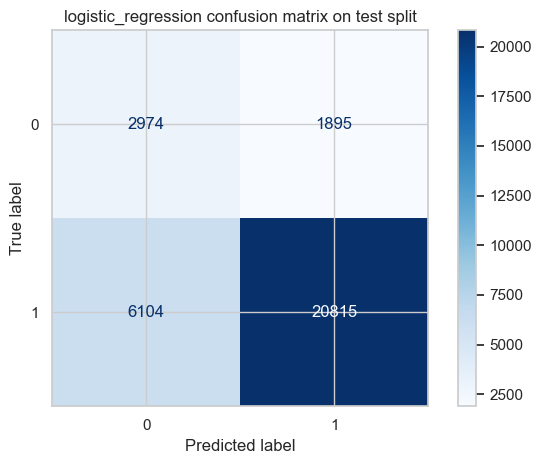

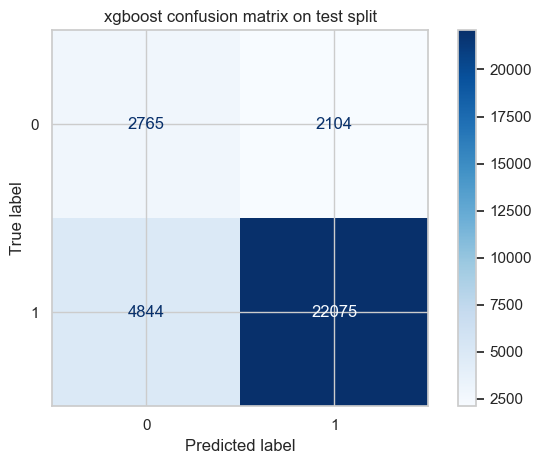

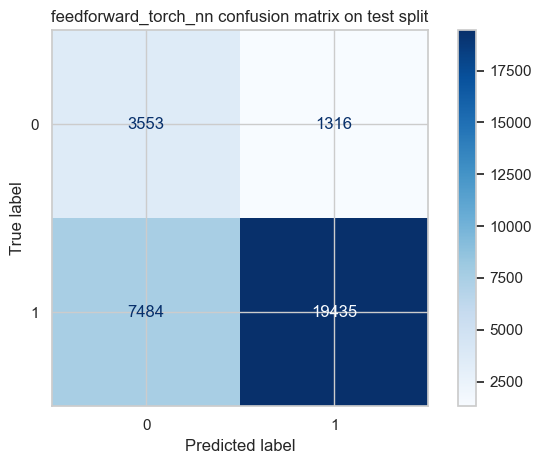

In [55]:
for name, model in models.items():
    proba = predict_proba_positive(model, X_test)
    y_pred = (proba >= 0.5).astype(int)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
    plt.title(f"{name} confusion matrix on test split")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"confusion_matrix_{name}_test.png", dpi=180)
    plt.show()


## 13. Threshold Simulation

The default threshold of 0.50 is an assumption, not a neutral fact. We test thresholds from 0.30 to 0.70 to show how precision, recall, F1, false-positive rate, and false-negative rate change.


In [56]:
THRESHOLDS = [0.30, 0.40, 0.50, 0.60, 0.70]
threshold_rows = []

for name, model in models.items():
    proba = predict_proba_positive(model, X_test)
    for threshold in THRESHOLDS:
        row = {"model": name, "split": "test"}
        row.update(metrics_at_threshold(y_test, proba, threshold=threshold))
        threshold_rows.append(row)

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.to_csv(TABLES_DIR / "threshold_simulation_results.csv", index=False)
threshold_df


,model,split,threshold,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn
0,logistic_regression,test,0.3,0.831666,0.680645,0.902418,0.898362,0.900385,0.537071,0.101638,24183,2615,2254,2736
1,logistic_regression,test,0.4,0.797691,0.690530,0.909662,0.845017,0.876148,0.463956,0.154983,22747,2259,2610,4172
2,logistic_regression,test,0.5,0.748364,0.692024,0.916557,0.773246,0.838824,0.389197,0.226754,20815,1895,2974,6104
3,logistic_regression,test,0.6,0.664276,0.687293,0.928251,0.654110,0.767434,0.279524,0.345890,17608,1361,3508,9311
4,logistic_regression,test,0.7,0.532213,0.655246,0.940420,0.477878,0.633726,0.167386,0.522122,12864,815,4054,14055
5,xgboost,test,0.3,0.845759,0.681144,0.901283,0.918459,0.909790,0.556172,0.081541,24724,2708,2161,2195
6,xgboost,test,0.4,0.822984,0.692594,0.907643,0.880568,0.893900,0.495379,0.119432,23704,2412,2457,3215
7,xgboost,test,0.5,0.781427,0.693966,0.912982,0.820053,0.864026,0.432122,0.179947,22075,2104,2765,4844
8,xgboost,test,0.6,0.714043,0.689424,0.920515,0.724915,0.811089,0.346067,0.275085,19514,1685,3184,7405
9,xgboost,test,0.7,0.595225,0.675291,0.936669,0.559865,0.700830,0.209283,0.440135,15071,1019,3850,11848


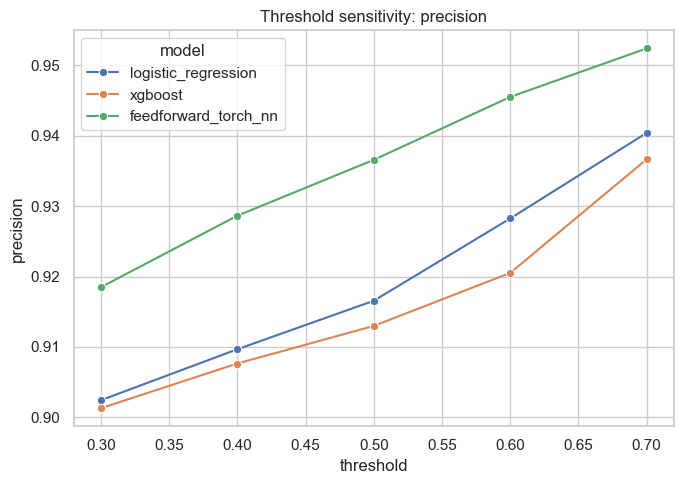

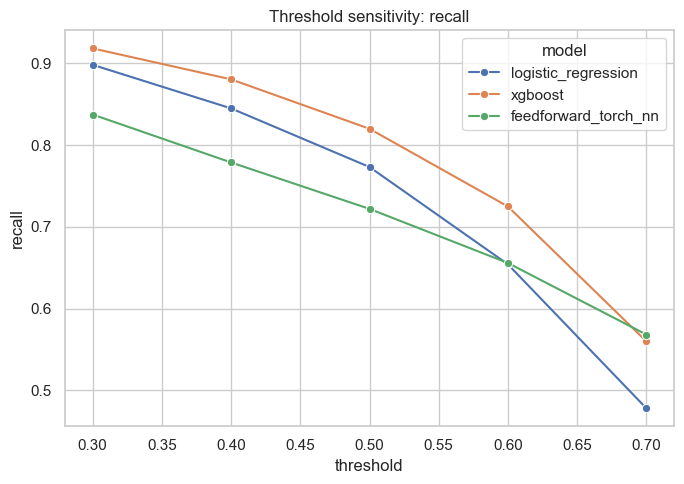

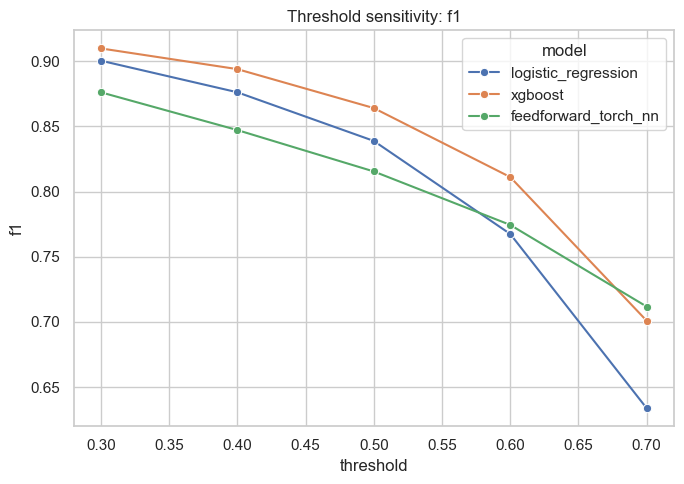

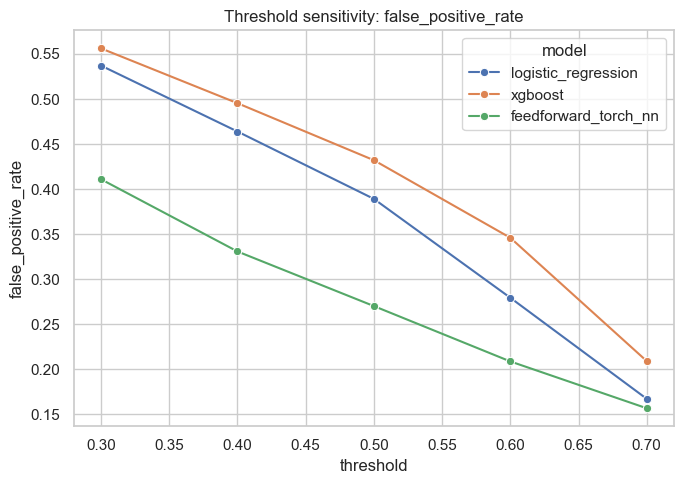

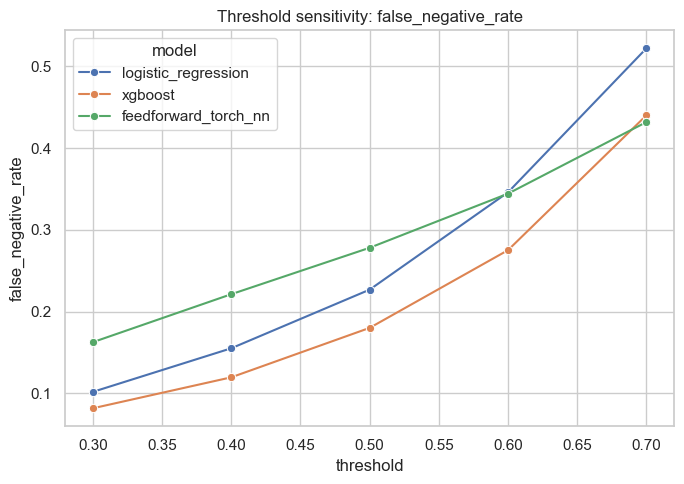

In [57]:
for metric in ["precision", "recall", "f1", "false_positive_rate", "false_negative_rate"]:
    plt.figure(figsize=(7, 5))
    sns.lineplot(data=threshold_df, x="threshold", y=metric, hue="model", marker="o")
    plt.title(f"Threshold sensitivity: {metric}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"threshold_{metric}.png", dpi=180)
    plt.show()


## 14. Validation-Selected Decision Thresholds

The threshold simulation shows sensitivity across fixed thresholds. For a reproducible test-set estimate, this section selects each model's threshold on the validation set by balanced accuracy and evaluates that threshold once on the temporal test set.


In [58]:
validation_threshold_rows = []
test_selected_threshold_rows = []
threshold_grid = np.round(np.arange(0.20, 0.81, 0.01), 2)

for model_name, model in models.items():
    valid_proba = predict_proba_positive(model, X_valid)
    valid_candidates = []
    for threshold in threshold_grid:
        row = {"model": model_name, "split": "validation", "threshold": float(threshold)}
        row.update(metrics_at_threshold(y_valid, valid_proba, threshold=threshold))
        valid_candidates.append(row)
    valid_frame = pd.DataFrame(valid_candidates)
    best_valid_row = valid_frame.sort_values(["balanced_accuracy", "f1"], ascending=False).iloc[0]
    validation_threshold_rows.append(best_valid_row.to_dict())

    test_proba = predict_proba_positive(model, X_test)
    test_row = {"model": model_name, "split": "test_selected_validation_threshold"}
    test_row.update(metrics_at_threshold(y_test, test_proba, threshold=float(best_valid_row["threshold"])))
    test_selected_threshold_rows.append(test_row)

validation_threshold_df = pd.DataFrame(validation_threshold_rows)
test_selected_threshold_df = pd.DataFrame(test_selected_threshold_rows)
selected_threshold_df = pd.concat([validation_threshold_df, test_selected_threshold_df], ignore_index=True)
selected_threshold_df.to_csv(TABLES_DIR / "proposal_validation_selected_thresholds.csv", index=False)
selected_threshold_df


,model,split,threshold,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn
0,logistic_regression,validation,0.40,0.803788,0.713804,0.900343,0.854974,0.877072,0.427367,0.145026,28386,3142,4210,4815
1,xgboost,validation,0.46,0.794910,0.719819,0.904802,0.837625,0.869919,0.397987,0.162375,27810,2926,4426,5391
2,feedforward_torch_nn,validation,0.46,0.767465,0.745787,0.924346,0.779796,0.845940,0.288221,0.220204,25890,2119,5233,7311
3,logistic_regression,test_selected_validation_threshold,0.40,0.797691,0.690530,0.909662,0.845017,0.876148,0.463956,0.154983,22747,2259,2610,4172
4,xgboost,test_selected_validation_threshold,0.46,0.798698,0.694405,0.911058,0.844756,0.876655,0.455946,0.155244,22740,2220,2649,4179
5,feedforward_torch_nn,test_selected_validation_threshold,0.46,0.739052,0.726902,0.934045,0.744418,0.828520,0.290614,0.255582,20039,1415,3454,6880


## 15. Subgroup Error Disparity Analysis

Here, algorithmic bias is operationalized as unequal false-positive and false-negative rates across geopolitical and tactical groups. This is model-behavior analysis, not a causal claim about the groups themselves.


In [59]:
def subgroup_error_analysis(model_name, model, X_frame, y_true, subgroup_column, threshold=0.5, min_group_size=50):
    if subgroup_column not in X_frame.columns:
        return pd.DataFrame()
    proba = predict_proba_positive(model, X_frame)
    y_pred = (proba >= threshold).astype(int)
    frame = pd.DataFrame({
        "group": X_frame[subgroup_column].astype("string").fillna("Unknown").to_numpy(),
        "y": np.asarray(y_true),
        "pred": y_pred,
    })
    rows = []
    for group, g in frame.groupby("group", dropna=False):
        if len(g) < min_group_size:
            continue
        fp = int(((g.pred == 1) & (g.y == 0)).sum())
        fn = int(((g.pred == 0) & (g.y == 1)).sum())
        tp = int(((g.pred == 1) & (g.y == 1)).sum())
        tn = int(((g.pred == 0) & (g.y == 0)).sum())
        rows.append({
            "model": model_name,
            "subgroup_column": subgroup_column,
            "group": group,
            "n": len(g),
            "base_success_rate": float(g.y.mean()),
            "false_positive_rate": fp / (fp + tn) if (fp + tn) else 0.0,
            "false_negative_rate": fn / (fn + tp) if (fn + tp) else 0.0,
            "tp": tp, "fp": fp, "tn": tn, "fn": fn,
        })
    return pd.DataFrame(rows)

subgroup_columns = ["region_txt", "country_txt", "attacktype1_txt", "targtype1_txt", "weaptype1_txt"]
subgroup_frames = []
for model_name, model in models.items():
    for subgroup_column in subgroup_columns:
        subgroup_frames.append(subgroup_error_analysis(model_name, model, X_test, y_test, subgroup_column))

subgroup_df = pd.concat([f for f in subgroup_frames if not f.empty], ignore_index=True)
subgroup_df.to_csv(TABLES_DIR / "subgroup_error_analysis.csv", index=False)
subgroup_df.sort_values(["false_positive_rate", "n"], ascending=[False, False]).head(20)


,model,subgroup_column,group,n,base_success_rate,false_positive_rate,false_negative_rate,tp,fp,tn,fn
56,logistic_regression,attacktype1_txt,Hostage Taking (Barricade Incident),166,0.981928,1.000000,0.024540,159,3,0,4
142,xgboost,attacktype1_txt,Hostage Taking (Barricade Incident),166,0.981928,1.000000,0.012270,161,3,0,2
228,feedforward_torch_nn,attacktype1_txt,Hostage Taking (Barricade Incident),166,0.981928,1.000000,0.006135,162,3,0,1
69,logistic_regression,targtype1_txt,Other,66,0.909091,1.000000,0.066667,56,6,0,4
155,xgboost,targtype1_txt,Other,66,0.909091,1.000000,0.133333,52,6,0,8
241,feedforward_torch_nn,targtype1_txt,Other,66,0.909091,1.000000,0.033333,58,6,0,2
83,logistic_regression,weaptype1_txt,Sabotage Equipment,51,0.980392,1.000000,0.280000,36,1,0,14
169,xgboost,weaptype1_txt,Sabotage Equipment,51,0.980392,1.000000,0.220000,39,1,0,11
255,feedforward_torch_nn,weaptype1_txt,Sabotage Equipment,51,0.980392,1.000000,0.120000,44,1,0,6
145,xgboost,attacktype1_txt,Unknown,4089,0.786256,0.954233,0.010264,3182,834,40,33


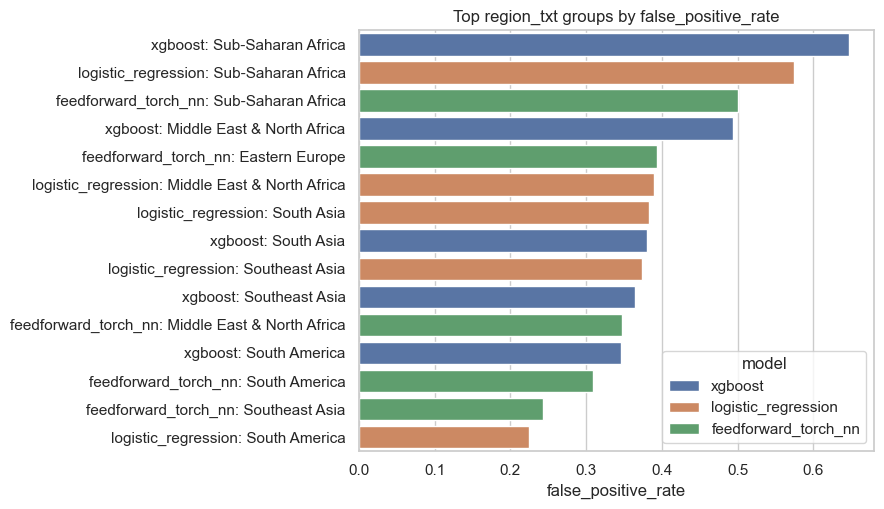

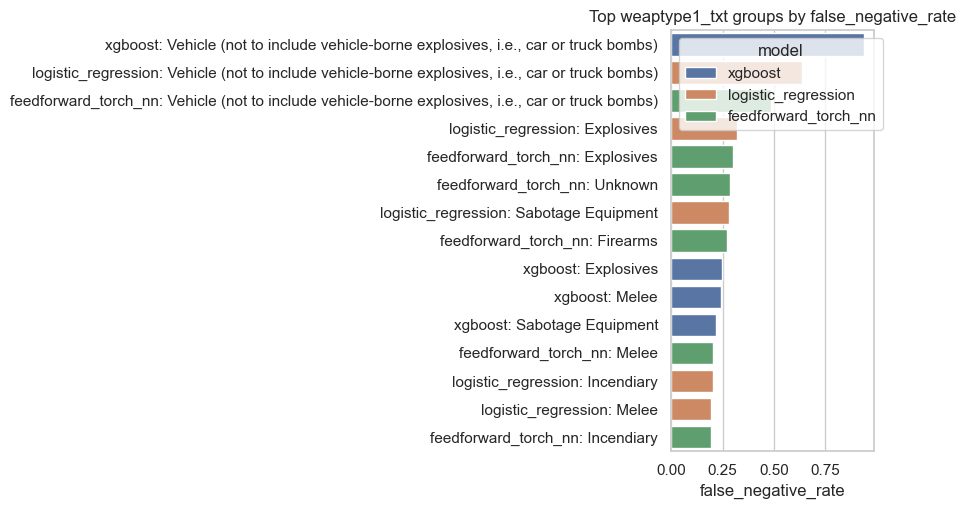

In [60]:
def plot_top_subgroups(subgroup_df, subgroup_column, metric, filename, top_n=15):
    frame = subgroup_df[subgroup_df["subgroup_column"] == subgroup_column].copy()
    frame = frame.sort_values(metric, ascending=False).head(top_n)
    if frame.empty:
        return
    frame["label"] = frame["model"] + ": " + frame["group"].astype(str)
    plt.figure(figsize=(9, max(4, 0.35 * len(frame))))
    sns.barplot(data=frame, x=metric, y="label", hue="model", dodge=False)
    plt.ylabel("")
    plt.title(f"Top {subgroup_column} groups by {metric}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=180)
    plt.show()

plot_top_subgroups(subgroup_df, "region_txt", "false_positive_rate", "subgroup_region_false_positive_rate.png")
plot_top_subgroups(subgroup_df, "weaptype1_txt", "false_negative_rate", "subgroup_weapon_false_negative_rate.png")


## 16. Subgroup Disparity Summary Statistics

This converts the subgroup error table into compact disparity metrics: max-min false-positive-rate and false-negative-rate gaps across sufficiently large groups.


In [ ]:
MIN_DISPARITY_GROUP_SIZE = 200

disparity_rows = []
if "subgroup_df" in globals() and not subgroup_df.empty:
    large_groups = subgroup_df[subgroup_df["n"] >= MIN_DISPARITY_GROUP_SIZE].copy()
    for (model_name, subgroup_column), g in large_groups.groupby(["model", "subgroup_column"]):
        disparity_rows.append({
            "model": model_name,
            "subgroup_column": subgroup_column,
            "n_groups": g["group"].nunique(),
            "min_group_size": int(g["n"].min()),
            "max_false_positive_rate": g["false_positive_rate"].max(),
            "min_false_positive_rate": g["false_positive_rate"].min(),
            "false_positive_rate_gap": g["false_positive_rate"].max() - g["false_positive_rate"].min(),
            "max_false_negative_rate": g["false_negative_rate"].max(),
            "min_false_negative_rate": g["false_negative_rate"].min(),
            "false_negative_rate_gap": g["false_negative_rate"].max() - g["false_negative_rate"].min(),
        })

disparity_summary_df = pd.DataFrame(disparity_rows)
disparity_summary_df.to_csv(TABLES_DIR / "proposal_subgroup_disparity_summary.csv", index=False)
disparity_summary_df.sort_values(["false_negative_rate_gap", "false_positive_rate_gap"], ascending=False)


## 17. Interpretability: Logistic Coefficients and SHAP for XGBoost

Logistic regression coefficients show the strongest linear associations after preprocessing. For XGBoost, SHAP values estimate each feature's contribution to model output. If SHAP is unavailable or too slow, the notebook falls back to XGBoost's built-in feature importances.


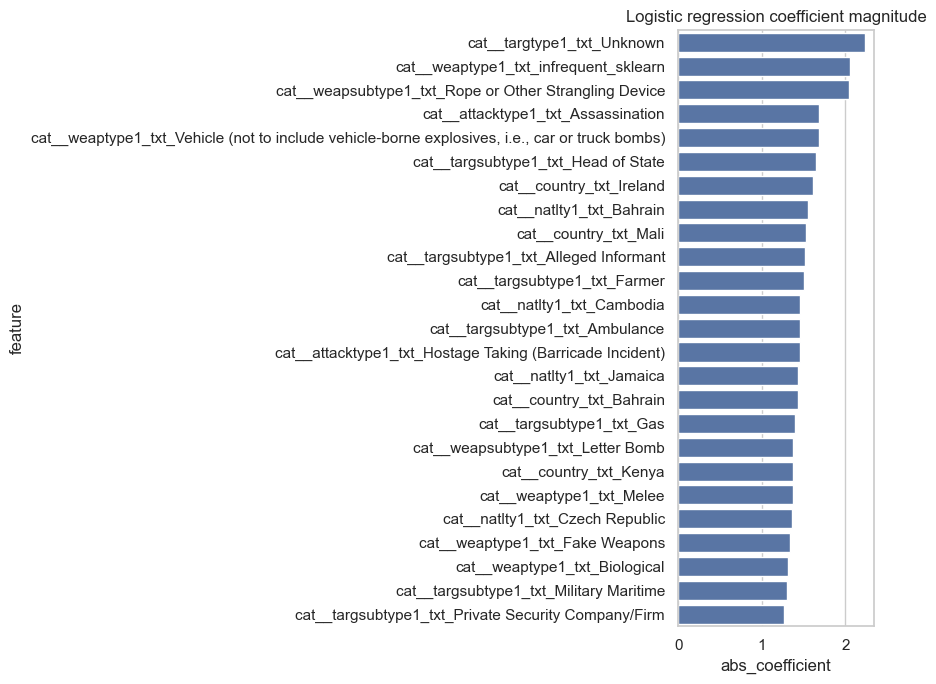

,feature,coefficient,abs_coefficient
198,cat__targtype1_txt_Unknown,-2.231155,2.231155
462,cat__weaptype1_txt_infrequent_sklearn,-2.055709,2.055709
484,cat__weapsubtype1_txt_Rope or Other Strangling...,2.044414,2.044414
171,cat__attacktype1_txt_Assassination,-1.685174,1.685174
461,cat__weaptype1_txt_Vehicle (not to include veh...,1.683652,1.683652
229,cat__targsubtype1_txt_Head of State,-1.647269,1.647269
85,cat__country_txt_Ireland,-1.611515,1.611515
319,cat__natlty1_txt_Bahrain,-1.555627,1.555627
106,cat__country_txt_Mali,1.528064,1.528064
205,cat__targsubtype1_txt_Alleged Informant,1.513821,1.513821


In [61]:
def get_feature_names(pipeline):
    return list(pipeline.named_steps["preprocessor"].get_feature_names_out())

importance_outputs = {}

if "logistic_regression" in models:
    lr_model = models["logistic_regression"]
    lr_features = get_feature_names(lr_model)
    lr_coef = lr_model.named_steps["model"].coef_.ravel()
    lr_importance = pd.DataFrame({"feature": lr_features, "coefficient": lr_coef})
    lr_importance["abs_coefficient"] = lr_importance["coefficient"].abs()
    lr_importance = lr_importance.sort_values("abs_coefficient", ascending=False).head(25)
    importance_outputs["logistic_regression"] = lr_importance

    plt.figure(figsize=(9, 7))
    sns.barplot(data=lr_importance, x="abs_coefficient", y="feature")
    plt.title("Logistic regression coefficient magnitude")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "importance_logistic_regression.png", dpi=180)
    plt.show()

lr_importance if "logistic_regression" in importance_outputs else None


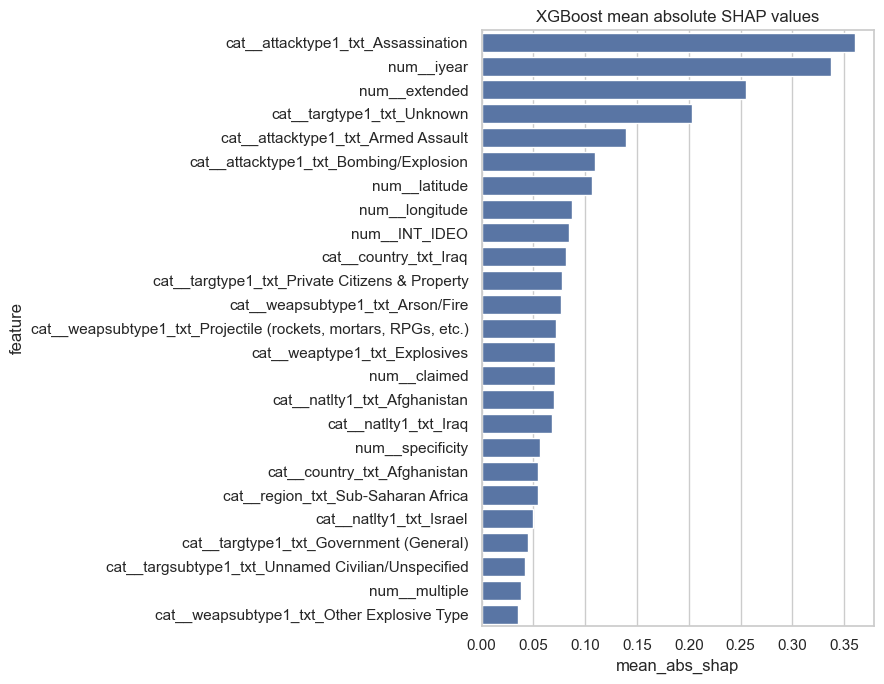

,feature,mean_abs_shap
171,cat__attacktype1_txt_Assassination,0.360656
0,num__iyear,0.337487
3,num__extended,0.255145
198,cat__targtype1_txt_Unknown,0.203464
170,cat__attacktype1_txt_Armed Assault,0.139643
172,cat__attacktype1_txt_Bombing/Explosion,0.109249
4,num__latitude,0.106934
5,num__longitude,0.087652
15,num__INT_IDEO,0.084462
84,cat__country_txt_Iraq,0.082007


In [62]:
if "xgboost" in models:
    xgb_pipeline = models["xgboost"]
    xgb_features = get_feature_names(xgb_pipeline)
    xgb_model = xgb_pipeline.named_steps["model"]
    shap_sample = X_test.sample(min(len(X_test), SHAP_SAMPLE_SIZE), random_state=RANDOM_STATE)
    transformed_sample = xgb_pipeline.named_steps["preprocessor"].transform(shap_sample)

    shap_available = False
    if RUN_SHAP:
        try:
            import shap
            shap_available = True
        except ImportError:
            print("SHAP is not installed; using XGBoost built-in feature importance instead.")

    if RUN_SHAP and shap_available:
        explainer = shap.TreeExplainer(xgb_model)
        shap_values = explainer.shap_values(transformed_sample)
        mean_abs_shap = np.abs(shap_values).mean(axis=0)
        xgb_importance = pd.DataFrame({
            "feature": xgb_features,
            "mean_abs_shap": mean_abs_shap,
        }).sort_values("mean_abs_shap", ascending=False).head(25)
        x_axis = "mean_abs_shap"
        title = "XGBoost mean absolute SHAP values"
    else:
        xgb_importance = pd.DataFrame({
            "feature": xgb_features,
            "importance": xgb_model.feature_importances_,
        }).sort_values("importance", ascending=False).head(25)
        x_axis = "importance"
        title = "XGBoost feature importance"

    importance_outputs["xgboost"] = xgb_importance
    plt.figure(figsize=(9, 7))
    sns.barplot(data=xgb_importance, x=x_axis, y="feature")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "importance_xgboost.png", dpi=180)
    plt.show()

    display(xgb_importance)
else:
    print("XGBoost model was not trained.")


## 18. Strict-Feature Leakage Sensitivity Audit

The proposal emphasizes prediction from initial tactical/geopolitical variables such as target type and weapon selection. This audit removes variables that may depend on event coding or post-outcome knowledge, then retrains Logistic Regression and XGBoost to test how sensitive conclusions are to modeling assumptions.


In [63]:
RUN_STRICT_FEATURE_AUDIT = True

POTENTIAL_CODING_TIME_OR_LEAKAGE_COLUMNS = [
    "extended", "claimed", "claim2", "claim3", "compclaim",
    "claimmode_txt", "claimmode2_txt", "claimmode3_txt",
    "alternative_txt", "crit1", "crit2", "crit3", "doubtterr",
]

strict_audit_df = pd.DataFrame()

if RUN_STRICT_FEATURE_AUDIT:
    strict_drop = [c for c in POTENTIAL_CODING_TIME_OR_LEAKAGE_COLUMNS if c in X_train.columns]
    strict_features = [c for c in X_train.columns if c not in strict_drop]
    strict_numeric = [c for c in present_numeric if c in strict_features]
    strict_categorical = [c for c in present_categorical if c in strict_features]
    print("Strict audit dropping:", strict_drop)

    def make_strict_preprocessor():
        numeric_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ])
        categorical_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
            ("onehot", make_one_hot_encoder()),
        ])
        return ColumnTransformer([
            ("num", numeric_pipeline, strict_numeric),
            ("cat", categorical_pipeline, strict_categorical),
        ], remainder="drop", sparse_threshold=0.3)

    strict_models = {
        "strict_logistic_regression": Pipeline([
            ("preprocessor", make_strict_preprocessor()),
            ("model", LogisticRegression(class_weight="balanced", max_iter=2000, solver="saga", random_state=RANDOM_STATE)),
        ])
    }
    if XGBOOST_AVAILABLE:
        positives = max(int((y_train == 1).sum()), 1)
        negatives = max(int((y_train == 0).sum()), 1)
        strict_models["strict_xgboost"] = Pipeline([
            ("preprocessor", make_strict_preprocessor()),
            ("model", XGBClassifier(
                n_estimators=350, max_depth=4, learning_rate=0.05, subsample=0.85, colsample_bytree=0.85,
                objective="binary:logistic", eval_metric="logloss", scale_pos_weight=negatives / positives,
                random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist", device=XGBOOST_DEVICE,
            )),
        ])

    strict_rows = []
    X_train_strict = X_train[strict_features].copy()
    X_valid_strict = X_valid[strict_features].copy()
    X_test_strict = X_test[strict_features].copy()
    for model_name, model in strict_models.items():
        print("Training", model_name)
        model.fit(X_train_strict, y_train)
        joblib.dump(model, MODELS_DIR / f"{model_name}.joblib")
        for split_name, X_split, y_split in [("validation", X_valid_strict, y_valid), ("test", X_test_strict, y_test)]:
            proba = predict_proba_positive(model, X_split)
            strict_rows.append(robust_binary_metrics(model_name, split_name, y_split, proba, 0.50))

    strict_audit_df = pd.DataFrame(strict_rows)
    strict_audit_df["dropped_columns"] = ", ".join(strict_drop)
    strict_audit_df.to_csv(TABLES_DIR / "proposal_strict_feature_audit.csv", index=False)
else:
    print("Strict feature audit skipped.")

strict_audit_df


Strict audit dropping: ['extended', 'claimed', 'doubtterr']
Training strict_logistic_regression
Training strict_xgboost


,model,split,threshold,roc_auc,average_precision_success,average_precision_failure,brier_score,mcc,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn,dropped_columns
0,strict_logistic_regression,validation,0.5,0.773524,0.926918,0.528384,0.176599,0.352152,0.754198,0.708510,0.906555,0.780187,0.838638,0.363166,0.219813,25903,2670,4682,7298,"extended, claimed, doubtterr"
1,strict_logistic_regression,test,0.5,0.762742,0.938783,0.453438,0.182816,0.307287,0.751888,0.691581,0.915873,0.778521,0.841630,0.395358,0.221479,20957,1925,2944,5962,"extended, claimed, doubtterr"
2,strict_xgboost,validation,0.5,0.787275,0.934864,0.561455,0.164977,0.368414,0.773457,0.711853,0.904658,0.808500,0.853880,0.384793,0.191500,26843,2829,4523,6358,"extended, claimed, doubtterr"
3,strict_xgboost,test,0.5,0.772036,0.942732,0.472586,0.163691,0.328006,0.782811,0.693689,0.912697,0.822170,0.865072,0.434792,0.177830,22132,2117,2752,4787,"extended, claimed, doubtterr"


## 19. Feature-Group Ablation Study

Ablations test whether performance depends on geography, time, or tactical variables. This directly supports the research question about how models weigh human-driven geopolitical and tactical features. To control runtime, the ablation uses the proposal XGBoost configuration.


In [ ]:
RUN_FEATURE_ABLATIONS = True

FEATURE_GROUPS_TO_DROP = {
    "drop_geography": ["region_txt", "country_txt", "latitude", "longitude", "natlty1_txt"],
    "drop_time": ["iyear", "imonth", "iday"],
    "drop_tactical_attack_target_weapon": ["attacktype1_txt", "targtype1_txt", "targsubtype1_txt", "weaptype1_txt", "weapsubtype1_txt"],
    "drop_uncertainty_claim": ["doubtterr", "guncertain1", "claimed"],
}

ablation_rows = []

if RUN_FEATURE_ABLATIONS and XGBOOST_AVAILABLE:
    positives = max(int((y_train == 1).sum()), 1)
    negatives = max(int((y_train == 0).sum()), 1)

    def train_ablation_xgb(ablation_name, drop_columns):
        keep_numeric = [c for c in present_numeric if c not in drop_columns]
        keep_categorical = [c for c in present_categorical if c not in drop_columns]
        keep_features = keep_numeric + keep_categorical
        numeric_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ])
        categorical_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
            ("onehot", make_one_hot_encoder()),
        ])
        preprocessor = ColumnTransformer([
            ("num", numeric_pipeline, keep_numeric),
            ("cat", categorical_pipeline, keep_categorical),
        ], remainder="drop", sparse_threshold=0.3)
        model = Pipeline([
            ("preprocessor", preprocessor),
            ("model", XGBClassifier(
                n_estimators=350, max_depth=4, learning_rate=0.05, subsample=0.85, colsample_bytree=0.85,
                objective="binary:logistic", eval_metric="logloss", scale_pos_weight=negatives / positives,
                random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist", device=XGBOOST_DEVICE,
            )),
        ])
        model.fit(X_train[keep_features], y_train)
        for split_name, X_split, y_split in [("validation", X_valid, y_valid), ("test", X_test, y_test)]:
            proba = predict_proba_positive(model, X_split[keep_features])
            row = robust_binary_metrics(f"xgboost_{ablation_name}", split_name, y_split, proba, 0.50)
            row["dropped_columns"] = ", ".join([c for c in drop_columns if c in X_train.columns])
            row["n_features_kept"] = len(keep_features)
            ablation_rows.append(row)
        return model

    # Include full XGBoost baseline for easy comparison.
    for split_name, X_split, y_split in [("validation", X_valid, y_valid), ("test", X_test, y_test)]:
        proba = predict_proba_positive(models["xgboost"], X_split)
        row = robust_binary_metrics("xgboost_full_feature_set", split_name, y_split, proba, 0.50)
        row["dropped_columns"] = ""
        row["n_features_kept"] = len(present_numeric + present_categorical)
        ablation_rows.append(row)

    for ablation_name, drop_cols in FEATURE_GROUPS_TO_DROP.items():
        print("Running ablation:", ablation_name)
        train_ablation_xgb(ablation_name, drop_cols)

feature_ablation_df = pd.DataFrame(ablation_rows)
feature_ablation_df.to_csv(TABLES_DIR / "proposal_feature_group_ablation.csv", index=False)
feature_ablation_df.sort_values(["split", "roc_auc"], ascending=[True, False])


## 20. Optional Rolling Temporal Validation

Rolling temporal validation tests whether conclusions are stable across historical periods. It is disabled by default because it retrains multiple models. Enable it for final manuscript robustness if runtime permits.


In [ ]:
RUN_ROLLING_TEMPORAL_VALIDATION = False

rolling_rows = []
rolling_windows = [
    {"train_end": 2008, "eval_start": 2009, "eval_end": 2011},
    {"train_end": 2011, "eval_start": 2012, "eval_end": 2014},
    {"train_end": 2014, "eval_start": 2015, "eval_end": 2017},
    {"train_end": 2017, "eval_start": 2018, "eval_end": int(X["iyear"].max())},
]

if RUN_ROLLING_TEMPORAL_VALIDATION and XGBOOST_AVAILABLE:
    for window_id, window in enumerate(rolling_windows, start=1):
        train_idx = X["iyear"] <= window["train_end"]
        eval_idx = (X["iyear"] >= window["eval_start"]) & (X["iyear"] <= window["eval_end"])
        if train_idx.sum() == 0 or eval_idx.sum() == 0:
            continue
        X_roll_train, y_roll_train = X.loc[train_idx].copy(), y.loc[train_idx].copy()
        X_roll_eval, y_roll_eval = X.loc[eval_idx].copy(), y.loc[eval_idx].copy()
        positives = max(int((y_roll_train == 1).sum()), 1)
        negatives = max(int((y_roll_train == 0).sum()), 1)
        roll_model = Pipeline([
            ("preprocessor", make_preprocessor()),
            ("model", XGBClassifier(
                n_estimators=250, max_depth=4, learning_rate=0.05, subsample=0.85, colsample_bytree=0.85,
                objective="binary:logistic", eval_metric="logloss", scale_pos_weight=negatives / positives,
                random_state=RANDOM_STATE + window_id, n_jobs=-1, tree_method="hist", device=XGBOOST_DEVICE,
            )),
        ])
        print("Rolling window", window_id, window)
        roll_model.fit(X_roll_train, y_roll_train)
        proba = predict_proba_positive(roll_model, X_roll_eval)
        row = robust_binary_metrics("rolling_xgboost", f"{window['eval_start']}-{window['eval_end']}", y_roll_eval, proba, 0.50)
        row.update(window)
        rolling_rows.append(row)
else:
    print("Rolling temporal validation skipped. Set RUN_ROLLING_TEMPORAL_VALIDATION=True for final robustness runs.")

rolling_temporal_df = pd.DataFrame(rolling_rows)
if not rolling_temporal_df.empty:
    rolling_temporal_df.to_csv(TABLES_DIR / "proposal_rolling_temporal_validation.csv", index=False)
rolling_temporal_df


## 21. Results Summary Prompts for the Manuscript

Use the generated tables and figures to answer these questions in the paper:

1. Which model performs best on temporal test data?
2. Does the SOTA model improve discrimination, or does it mainly improve the majority class?
3. Which features dominate the Logistic Regression and XGBoost explanations?
4. How sensitive are conclusions to moving the decision threshold from 0.30 to 0.70?
5. Which regions, weapon types, target types, or countries show the largest error disparities?
6. Are those disparities due to model behavior, class imbalance, small subgroup size, or historical reporting patterns?


In [64]:
print("Saved models to:", MODELS_DIR)
print("Saved tables to:", TABLES_DIR)
print("Saved figures to:", FIGURES_DIR)
print("Proposal robust metrics:", TABLES_DIR / "proposal_robust_model_metrics.csv")
print("Proposal validation-selected thresholds:", TABLES_DIR / "proposal_validation_selected_thresholds.csv")
print("Proposal XGBoost learning curves:", TABLES_DIR / "proposal_xgboost_learning_curves.csv")
print("Proposal strict-feature audit:", TABLES_DIR / "proposal_strict_feature_audit.csv")
print("Proposal bootstrap CIs:", TABLES_DIR / "proposal_bootstrap_confidence_intervals.csv")
print("Proposal calibration curves:", TABLES_DIR / "proposal_calibration_curves.csv")
print("Proposal feature-group ablation:", TABLES_DIR / "proposal_feature_group_ablation.csv")
print("Proposal subgroup disparity summary:", TABLES_DIR / "proposal_subgroup_disparity_summary.csv")
print("Optional rolling temporal validation:", TABLES_DIR / "proposal_rolling_temporal_validation.csv")
print("Notebook complete.")


Saved models to: c:\Documents\Compsci\CSELEC2C\Project\models
Saved tables to: c:\Documents\Compsci\CSELEC2C\Project\results\tables
Saved figures to: c:\Documents\Compsci\CSELEC2C\Project\results\figures
Proposal robust metrics: c:\Documents\Compsci\CSELEC2C\Project\results\tables\proposal_robust_model_metrics.csv
Proposal validation-selected thresholds: c:\Documents\Compsci\CSELEC2C\Project\results\tables\proposal_validation_selected_thresholds.csv
Proposal XGBoost learning curves: c:\Documents\Compsci\CSELEC2C\Project\results\tables\proposal_xgboost_learning_curves.csv
Proposal strict-feature audit: c:\Documents\Compsci\CSELEC2C\Project\results\tables\proposal_strict_feature_audit.csv
Notebook complete.
